In [1]:
# Problem 2: Convolutional Neural Networks on CIFAR-10

In [2]:
# Import CIFAR-10 directly from Keras
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 81ms/step - accuracy: 0.2820 - loss: 1.9101 - val_accuracy: 0.5128 - val_loss: 1.3790
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 79ms/step - accuracy: 0.4979 - loss: 1.3883 - val_accuracy: 0.5823 - val_loss: 1.1627
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.5761 - loss: 1.1989 - val_accuracy: 0.6307 - val_loss: 1.0420
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.6238 - loss: 1.0780 - val_accuracy: 0.6490 - val_loss: 0.9999
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 79ms/step - accuracy: 0.6546 - loss: 0.9917 - val_accuracy: 0.6713 - val_loss: 0.9362
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.6791 - loss: 0.9231 - val_accuracy: 0.6791 - val_loss: 0.9244
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.7018 - loss: 0.8603 - val_accuracy: 0.6927 - val_loss: 0.8661
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 80ms/step - accuracy: 0.7162 - loss: 0.8178 - 

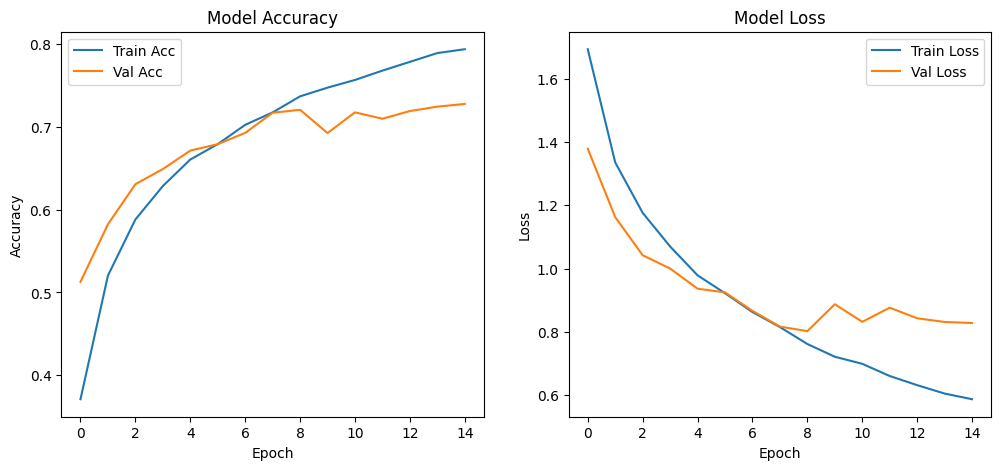

In [3]:
# 1. Preprocess the data
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Normalize pixel values to [0,1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Build the CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# 3. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# 5. Evaluate performance
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

# 6. Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

CNN results:

CNN outperofmed MLPS's accuracy. It reached a test accuracy of 72.8%. The training and valdaition loss both dropped and then stablized. No major overfitting observed. In reviewing the training output we see the valdation accuracy steadily climbed and held between approximately 70 and 80%. This output prooved that CNNs can handle image data better becuase ut captures spatial patterns that MPLs miss and this leads to better generalization.